In [1]:
from google.colab import files
upload = files.upload()

Saving Advertising.csv to Advertising.csv


First 5 Rows
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Shape of Dataset
(200, 5)

Columns
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

Missing Values
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Statistical Summary
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


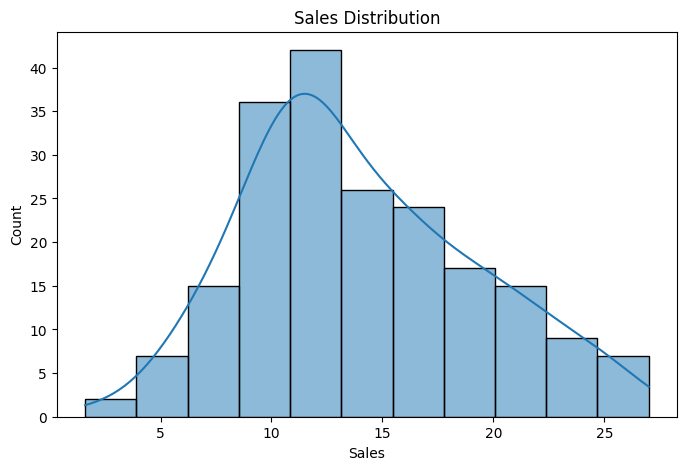

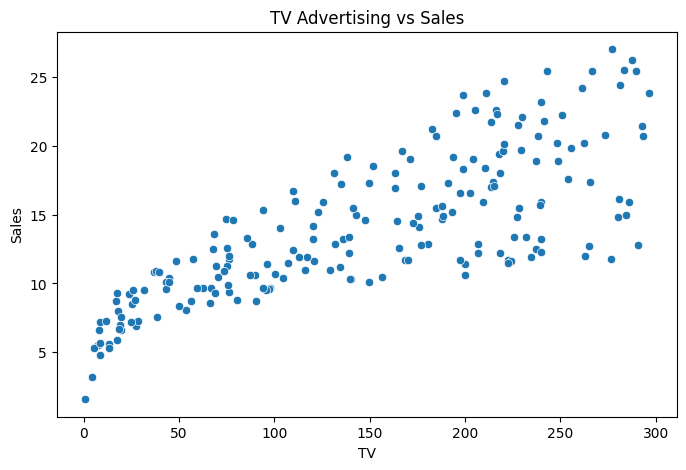

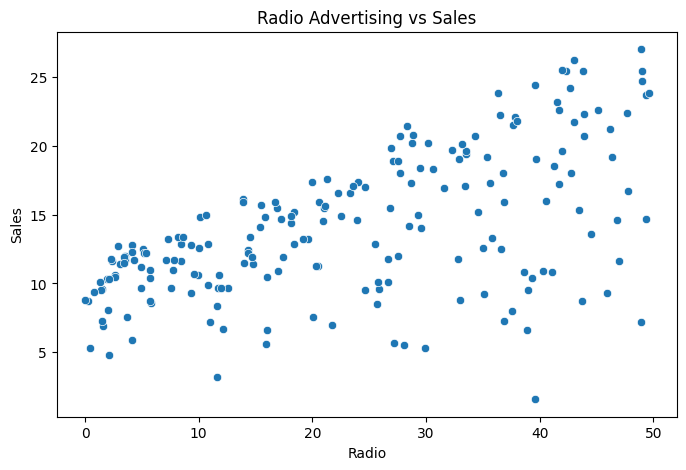

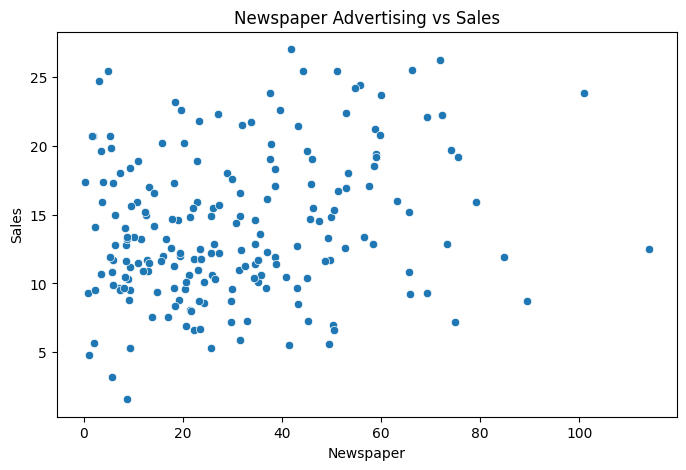

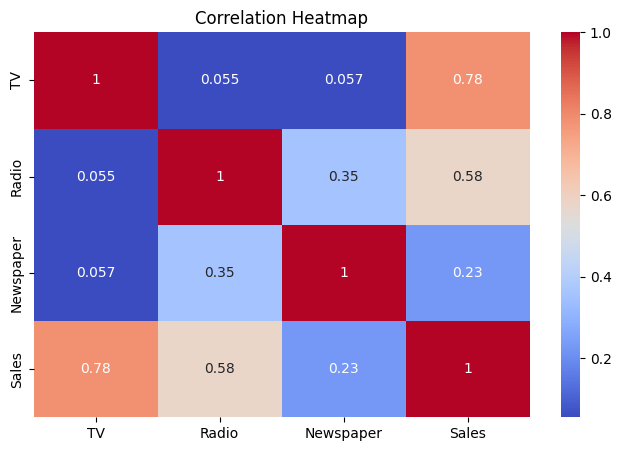


Model Performance
Mean Absolute Error: 1.4607567168117603
Mean Squared Error: 3.1740973539761033
R2 Score: 0.899438024100912


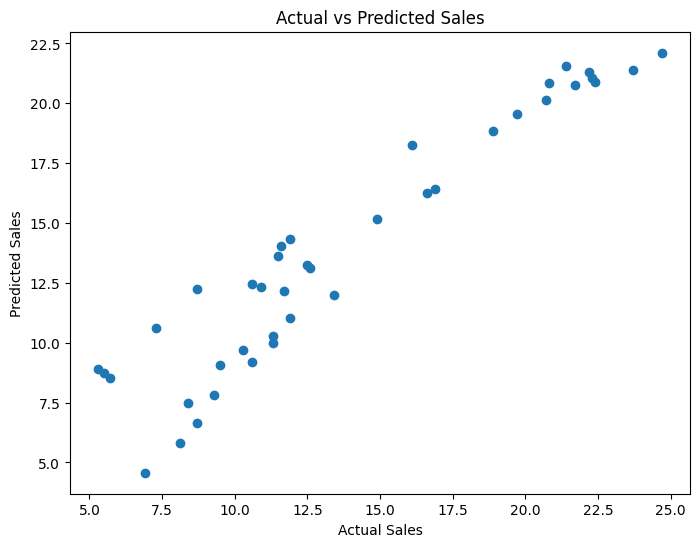


Feature Importance
     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


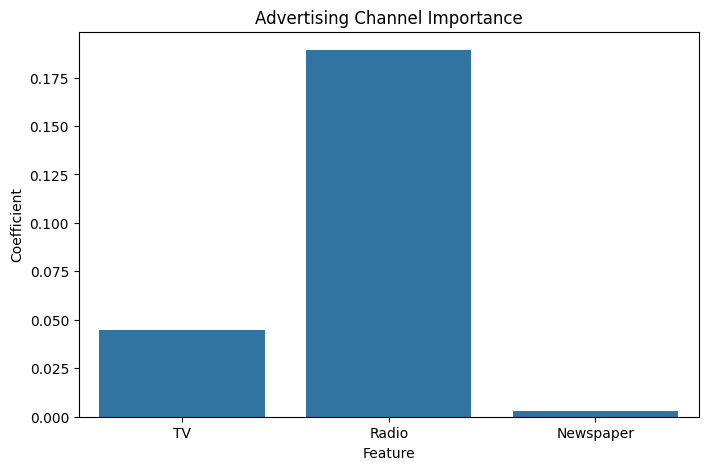


Predicted Sales: 17.711267032551877

Key Insights
1. TV advertising has the strongest impact on sales.
2. Radio advertising positively influences sales.
3. Newspaper advertising has relatively lower impact.
4. Businesses should invest more in TV and Radio marketing.
5. Machine Learning can help forecast future sales.


In [2]:
# =====================================
# SALES PREDICTION USING PYTHON
# CodeAlpha Task 4
# =====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# =====================================
# LOAD DATASET
# =====================================

df = pd.read_csv("Advertising.csv")

print("First 5 Rows")
print(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nColumns")
print(df.columns)

# =====================================
# DATA CLEANING
# =====================================

df.drop("Unnamed: 0", axis=1, inplace=True)

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

# =====================================
# DATA VISUALIZATION
# =====================================

plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], kde=True)
plt.title("Sales Distribution")
plt.show()

# TV vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["TV"], y=df["Sales"])
plt.title("TV Advertising vs Sales")
plt.show()

# Radio vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Radio"], y=df["Sales"])
plt.title("Radio Advertising vs Sales")
plt.show()

# Newspaper vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Newspaper"], y=df["Sales"])
plt.title("Newspaper Advertising vs Sales")
plt.show()

# =====================================
# CORRELATION HEATMAP
# =====================================

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# =====================================
# FEATURES AND TARGET
# =====================================

X = df.drop("Sales", axis=1)

y = df["Sales"]

# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# MODEL TRAINING
# =====================================

model = LinearRegression()

model.fit(X_train, y_train)

# =====================================
# PREDICTIONS
# =====================================

y_pred = model.predict(X_test)

# =====================================
# MODEL EVALUATION
# =====================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# =====================================
# ACTUAL VS PREDICTED
# =====================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

# =====================================
# FEATURE IMPORTANCE
# =====================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Feature",
    y="Coefficient"
)

plt.title("Advertising Channel Importance")
plt.show()

# =====================================
# SAMPLE PREDICTION
# =====================================

sample = pd.DataFrame({
    "TV":[200],
    "Radio":[30],
    "Newspaper":[40]
})

prediction = model.predict(sample)

print("\nPredicted Sales:", prediction[0])

# =====================================
# INSIGHTS
# =====================================

print("\nKey Insights")

print("1. TV advertising has the strongest impact on sales.")
print("2. Radio advertising positively influences sales.")
print("3. Newspaper advertising has relatively lower impact.")
print("4. Businesses should invest more in TV and Radio marketing.")
print("5. Machine Learning can help forecast future sales.")